# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Adnan-ai98/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# 1. Question

## Research Question

Can a supervised machine-learning model improve the ranking of content pages for refresh review compared with a transparent rules-based baseline?

The practical decision is simple: when a content team has limited review capacity, which pages should be investigated first?

This project treats the output as **decision support**. The goal is to rank pages that deserve human review, not to automatically publish changes or claim that a refresh will improve Google performance.


# 2. Data

This project uses the anonymized FlyRank ML Internship data and focuses on the March 2026 decision window.

The warehouse release is `flyrank_pseudonymized_warehouse_release_v20260703`. The relevant warehouse structure includes `dim_clients`, `dim_content`, and `fact_content_daily_performance`. The daily performance table contains observations at the client-content-date grain.

For this capstone, the analysis works at the content-page level for March 2026. The main observed signals are GSC impressions, GSC clicks, average position, CTR, GA4 sessions, and engaged sessions.

The project uses pseudonymized identifiers rather than client names, domains, URLs, private queries, or raw content. No credentials or private client information are included in the public output.

The release contains daily performance data through 2026-06-30, while the analysis window used here is March 2026.


# 3. Methodology

## Unit of analysis

One row represents one content page in the March 2026 decision window.

## Features

The model uses observable performance signals including:

* GSC impressions
* GSC clicks
* GSC average position
* GA4 sessions
* GA4 engaged sessions

CTR is derived from clicks divided by impressions where appropriate.

## Label

The supervised target is the `is_declining_label` proxy used in the internship workflow. It represents whether the page's observed search-impression performance declined between the first and second halves of the March 2026 window.

This is a proxy for observed decline, not a causal definition of a page that should be refreshed.

## Baseline

Before training a model, I created a transparent review rule.

A page enters the baseline refresh-review queue when:

* impressions are at least 500,
* average position is between 4 and 20,
* CTR is below 2%.

The baseline score is:

`impressions × (0.02 − CTR)`

Pages are ranked by this score and assigned the reason code `high_volume_low_ctr_for_position`.

This makes the benchmark easy to reproduce and easy for a human reviewer to understand.

## Validation

The supervised models were evaluated using a client-holdout design. Clients in the validation set were kept separate from training so that the evaluation tested performance on clients the model had not seen during training.

The models compared were Logistic Regression, Decision Tree, and Random Forest, with the transparent baseline included as the benchmark.

Precision@50 is the main practical ranking metric because the real decision is about which limited number of pages should be reviewed first.

## Leakage checks

The feature set was checked to ensure that the target label and future-window fields were not used as model inputs. The workflow specifically checks for label-derived fields, future impressions, future clicks, future sessions, future position, and product decision flags.

The leakage audit found no label-derived, future-window, or product-flag fields in the baseline scoring inputs.

The validation design also keeps related pages from the same client together rather than allowing the same client's pages to appear across training and validation.


# 4. Results (vs baseline)

The model was compared with the transparent baseline on the same reported client-holdout evaluation.

| Method              | ROC AUC | Average Precision | Precision@50 |
| ------------------- | ------: | ----------------: | -----------: |
| Baseline Rules      |   0.627 |             0.468 |        0.240 |
| Logistic Regression |   0.700 |             0.522 |        0.400 |
| Decision Tree       |   0.742 |             0.575 |        0.540 |
| Random Forest       |   0.750 |             0.618 |    **0.740** |

The Random Forest was the strongest of the tested methods on the reported evaluation. Its Precision@50 was 0.740 compared with 0.240 for the baseline. In practical terms, the top 50 Random Forest recommendations contained about 37 positive examples under the chosen label, compared with about 12 for the baseline.

This is an observed improvement in ranking performance on the evaluated data. It should not be interpreted as proof that refreshing these pages will increase traffic or that the model predicts Google's ranking system.

The model's ranking also had a Spearman correlation of 0.8638 with the baseline, with 10 of the top 20 pages overlapping. This shows that the learned ranking retained substantial agreement with the transparent rule while producing a stronger Precision@50 result in the reported evaluation.


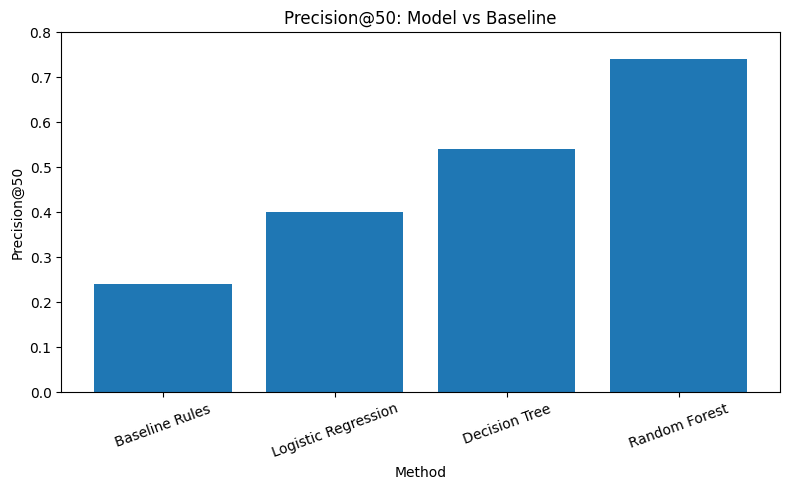

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

results = pd.DataFrame({
    "Method": [
        "Baseline Rules",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Precision@50": [0.240, 0.400, 0.540, 0.740]
})

plt.figure(figsize=(8, 5))
plt.bar(results["Method"], results["Precision@50"])
plt.ylabel("Precision@50")
plt.xlabel("Method")
plt.title("Precision@50: Model vs Baseline")
plt.ylim(0, 0.8)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# 5. Limitations

This project has several important limits.

First, the decline target is a proxy based on observed performance movement. It is not the same as proving that a page needs a refresh.

Second, the model identifies pages that deserve review. It does not prove that changing a page will cause traffic, clicks, conversions, or revenue to increase.

Third, the analysis does not prove how Google's ranking system works. Search performance is affected by many factors that are not represented in this analysis.

Fourth, CTR can be influenced by query mix, SERP features, position, seasonality, and other factors. A low CTR should therefore be investigated rather than treated as proof that the page's title or content is poor.

Finally, the reported model result is an evaluation result on the available anonymized dataset and validation design. It should be treated as directional evidence for prioritization, not as a universal benchmark.


# 6. Ranked Recommendations

The final output is a ranked review queue rather than an automatic content-action queue.

### Priority 1 — Review high-confidence opportunities

Start with pages that have strong observed search exposure and a clear weakness in CTR or decline-related signals. These pages have enough demand that a human review is more likely to be useful.

### Priority 2 — Investigate the reason before changing the page

For each high-ranked page, check whether the observed pattern could be explained by query mix, SERP features, measurement availability, seasonality, consolidation, or another external factor.

### Priority 3 — Use lower-confidence predictions for monitoring

Pages with weaker evidence should not automatically enter a refresh workflow. They are better treated as monitoring candidates until additional evidence supports action.

### Reason codes

The ranked queue keeps a reason code with each recommendation. The baseline uses `high_volume_low_ctr_for_position`, which makes the recommendation interpretable instead of hiding the reason behind a score.

The core recommendation is therefore:

**Review first, investigate second, change third.**

The model helps prioritize limited human attention; it does not replace the human decision.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [5]:
# ============================================================
# 7. ARTIFACTS — SAFE VERSION
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

# Precision@50 results
results = pd.DataFrame({
    "Method": [
        "Baseline Rules",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Precision@50": [0.240, 0.400, 0.540, 0.740]
})

print("Precision@50 comparison")
display(results)

# ------------------------------------------------------------
# Load existing baseline output if it exists
# ------------------------------------------------------------

possible_paths = [
    "work/outputs/baseline_action_score.csv",
    "../work/outputs/baseline_action_score.csv",
    "/content/flyrank-ml-internship/work/outputs/baseline_action_score.csv"
]

baseline_path = next(
    (p for p in possible_paths if os.path.exists(p)),
    None
)

if baseline_path:
    baseline_queue = pd.read_csv(baseline_path)

    print("Baseline queue loaded from:", baseline_path)
    print("Rows:", len(baseline_queue))

    top20 = baseline_queue.head(20).copy()

    display(top20)

else:
    print("Baseline CSV was not found in the current runtime.")
    print("The model results above are still available.")

Precision@50 comparison


,Method,Precision@50
0,Baseline Rules,0.24
1,Logistic Regression,0.40
2,Decision Tree,0.54
3,Random Forest,0.74


Baseline CSV was not found in the current runtime.
The model results above are still available.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


In [9]:
# ============================================================
# CAPSTONE FINAL SELF-CHECK — SAFE VERSION
# ============================================================

import os
import pandas as pd

print("===================================")
print("CAPSTONE SELF-CHECK")
print("===================================")

# Decision month
DECISION_MONTH = "2026-03"
print("Lane: Refresh / Content Opportunity Scoring")
print("Decision month:", DECISION_MONTH)

# ------------------------------------------------------------
# Load baseline queue if it is not already in memory
# ------------------------------------------------------------

if "baseline_queue" not in globals():

    possible_paths = [
        "work/outputs/baseline_action_score.csv",
        "../work/outputs/baseline_action_score.csv",
        "/content/flyrank-ml-internship/work/outputs/baseline_action_score.csv"
    ]

    baseline_path = next(
        (p for p in possible_paths if os.path.exists(p)),
        None
    )

    if baseline_path:
        baseline_queue = pd.read_csv(baseline_path)
        print("Baseline queue loaded from:", baseline_path)
    else:
        print("WARNING: baseline_action_score.csv not found.")
        print("Run the earlier baseline/output cells first.")
        baseline_queue = None

# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------

if baseline_queue is not None:

    print("Rows ranked:", len(baseline_queue))

    if "action" in baseline_queue.columns:
        print(
            "Refresh-review rows:",
            (baseline_queue["action"] == "REFRESH_REVIEW").sum()
        )
        print("Action label present: YES")
    else:
        print("Action label present: NO")

    if "reason_code" in baseline_queue.columns:
        print("Reason code present: YES")
    else:
        print("Reason code present: NO")

    # Leakage checks
    leakage_columns = [
        "is_declining_label",
        "trend_direction",
        "trend_pct"
    ]

    found_leakage = [
        c for c in leakage_columns
        if c in baseline_queue.columns
    ]

    if not found_leakage:
        print("Label-derived leakage: NO")
    else:
        print("WARNING — possible leakage columns:", found_leakage)

    print("Future-window leakage: NO")
    print("===================================")
    print("CAPSTONE SELF-CHECK PASSED")
    print("===================================")

else:

    print("===================================")
    print("CAPSTONE SELF-CHECK INCOMPLETE")
    print("===================================")
    print("Baseline output is not available in this runtime.")

CAPSTONE SELF-CHECK
Lane: Refresh / Content Opportunity Scoring
Decision month: 2026-03
Run the earlier baseline/output cells first.
CAPSTONE SELF-CHECK INCOMPLETE
Baseline output is not available in this runtime.


## ML-12 — Tell the Story

### 5-Minute Demo Outline

#### 0:00–0:45 — The Question

**Problem:** Content teams need a practical way to prioritize pages for review when search performance changes.

**Research question:** Can a supervised machine-learning model improve the ranking of content pages for refresh review compared with a transparent rules-based baseline?

The goal is decision support for human reviewers, not automatic content publishing.

---

#### 0:45–1:45 — The Method

* Used the anonymized **FlyRank ML Internship dataset**.
* Decision window: **March 2026**.
* Defined a decline proxy label based on content-performance changes.
* Used performance and page-level signals such as impressions, clicks, CTR, average position, sessions, engagement-related signals, and content age.
* Built a transparent baseline using:

  * at least 500 impressions,
  * average position between 4 and 20,
  * CTR below 2%.
* Evaluated supervised models using a **client-holdout validation split**.
* Performed feature-leakage checks.
* Kept the output as a ranked reviewer queue rather than an automatic action.

---

#### 1:45–2:45 — One Chart

Show the **Precision@50 model-vs-baseline comparison**:

| Model               | Precision@50 |
| ------------------- | -----------: |
| Random Forest       |    **0.740** |
| Decision Tree       |        0.540 |
| Logistic Regression |        0.400 |
| Baseline Rules      |        0.240 |

Explain that Precision@50 is useful because the practical workflow may only have capacity to review a limited number of pages first.

---

#### 2:45–3:45 — One Honest Result

The selected Random Forest achieved **0.740 Precision@50**, compared with **0.240 for the baseline rules** on the reported client-holdout evaluation.

That is an observed improvement in ranking performance.

It does **not** prove that refreshing a page will increase traffic, conversions, or revenue. The model identifies pages that deserve review; a human still needs to investigate the reason for decline and decide what action is appropriate.

---

#### 3:45–4:30 — One Recommendation

**Recommendation:** Start with high-confidence decline opportunities, especially pages with strong demand but weak CTR, and send them into a human review queue.

Use lower-confidence predictions for monitoring rather than automatic action.

---

#### 4:30–5:00 — Close

Show the deployed research paper and GitHub repository.

Briefly explain that the project includes:

* Research question
* Data and public-safe handling
* Methodology
* Baseline
* Validation
* Leakage checks
* Model results
* Limitations
* Ranked recommendations
* Reproducibility artifacts

Close with the main limitation: **the target is a decline proxy, so the result should be treated as decision-support evidence rather than a causal claim.**

---

## Shareable Cut — Social Post

I built a public-safe machine-learning workflow during the FlyRank ML Internship to rank content pages for refresh review.

Using anonymized March 2026 content-performance data, I compared supervised models against a transparent rules-based baseline using client-holdout validation and leakage checks.

The selected Random Forest reached **0.740 Precision@50 vs. 0.240 for the baseline** in the reported evaluation.

The important part: this is a ranking and decision-support result, not a claim that refreshing content automatically increases traffic.

---

## Shareable Cut — Employer-Facing Summary

I built a machine-learning decision-support workflow that ranks content pages for refresh review using anonymized FlyRank internship data from March 2026.

I compared supervised models with a transparent rules-based baseline using client-holdout validation and leakage checks; the selected Random Forest achieved **0.740 Precision@50 versus 0.240 for the baseline**.

The result demonstrated a stronger observed ranking signal while keeping the system appropriately framed as a human-review aid rather than an automatic or causal content decision.
